In [11]:
!nvidia-smi

Sat Apr 18 13:40:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.06              Driver Version: 555.42.06      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:42:00.0 Off |                    0 |
| N/A   51C    P0             28W /   72W |     471MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'
import torch

print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_name(1))

2
NVIDIA L4
NVIDIA L4


In [13]:
import yaml
import torch
import seaborn as sns
from datetime import datetime
from DRF.BayesianOptimiser import BayesianOptimiser
from DRF.data_utils import prepare_tensor_datasets_ABC
from DRF.models import initialize_model
import pandas as pd

import torch
import os
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeat
from pyproj import Transformer
from global_land_mask import globe
import ast

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/home/mhen/.local/share/fonts/IBMPlexSerif-Regular.ttf"
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.sans-serif"] = [font_prop.get_name()]

sns.set_theme(
    #context="talk",#affects font size
    style="whitegrid",
    palette="colorblind",
    font="IBM Plex Serif",
    rc={
        "font.family": "IBM Plex Serif",

        # Axes
        "axes.titlesize": 18,
        "axes.labelsize": 15,
        "axes.titleweight": "bold",
        "axes.labelweight": "regular",
        "axes.spines.top": False,
        "axes.spines.right": False,

        # Tick labels
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,

        # Legend
        "legend.fontsize": 13,
        "legend.title_fontsize": 14,
        "legend.frameon": False,

        # Lines & markers
        "lines.linewidth": 2.0,
        "lines.markersize": 6,

        # Grid
        "grid.linewidth": 0.7,
        "grid.alpha": 0.35,

        # Figure
        "figure.figsize": (6.5, 4.5),
        "figure.dpi": 100
    }
)




def EASE2toWGS84(x, y, return_vals="both", lon_0=0, lat_0=90):

    valid_return_vals = ['both', 'lon', 'lat']
    assert return_vals in ['both', 'lon', 'lat'], f"return_val: {return_vals} is not in valid set: {valid_return_vals}"
    EASE2 = f"+proj=laea +lon_0={lon_0} +lat_0={lat_0} +x_0=0 +y_0=0 +ellps=WGS84 +towgs84=0,0,0,0,0,0,0 +units=m +no_defs"
    WGS84 = "+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs"
    transformer = Transformer.from_crs(EASE2, WGS84)
    lon, lat = transformer.transform(x, y)
    if return_vals == "both":
        return lon, lat
    elif return_vals == "lon":
        return lon
    elif return_vals == "lat":
        return lat

In [14]:
#first get all track nos
tracks_dir = '/home/mhen/data/cs2s3/per_track/jan20/drf/week_interp/cs2s3'
filenames = os.listdir(tracks_dir)

tracknos = []
for file in filenames:
    trackno = file.split('track')[-1].split('.')[0] #isolate number
    tracknos.append(trackno)

#there should be two of each number - keep one of each duplicate value
dup_tracks = {track for track in tracknos if tracknos.count(track) == 2}
dup_tracks = sorted(dup_tracks, key=int)

In [15]:
linear_df = pd.read_csv('/home/mhen/2020-01_lin_interp.csv')

In [16]:
week = ['2020-01-01','2020-01-02','2020-01-03','2020-01-04','2020-01-05','2020-01-06','2020-01-07']

In [17]:
week_df = linear_df.loc[linear_df['date_string'].isin(week)]
cs2_week_df = week_df.loc[week_df['satellite']=='cs2']
tracks_in_cs2 = cs2_week_df['track'].unique()
print(tracks_in_cs2)

[1250 1252 1256 1257 1275 1276 1278 1279 1295 1297 1300 1301 1320 1321
 1323 1324 1325 1330 1342 1343 1344 1346 1350 1368 1370 1372 1386 1387
 1390 1392 1412 1413 1414 1416 1417 1420 1433 1434 1435 1436 1439 1454
 1455 1457 1459 1474 1475 1476 1479 1481 1501 1503 1504 1506 1507 1510
 1524 1526 1527 1528 1532 1548 1550 1551 1553]


In [18]:
def read_config(path):
    with open(path,'r') as f:
        config = yaml.safe_load(f)
    return config
def add_track_to_name(dir, filename,track_no,expand=True):
    if expand == True:
        results_dir = dir.replace('~','/home/mhen')
    elif expand == False:
        results_dir = dir
    name = filename.split('.')[0]
    ext = filename.split('.')[1]

    path = f'{results_dir}{name}_track{track_no}.{ext}'
    print(path)
    return path
#define target month as string
target_month = "2020-01"

def interpolate(config, tracks, results_dir):

    obs_data_path = config["data"]["obs_data_dir"] + config['data']['obs_data_name']
    test_data_path = config["data"]["obs_data_dir"] + config['data']['test_data_name']
    obs_extension = config['data']['obs_data_ext']
    test_extension = config['data']['test_data_ext']

    for i, track in enumerate(dup_tracks):
        print(f'Checking track {track}, {i+1} of {len(dup_tracks)}')

        #create all paths here, inserting tracknumber
        obs_path = obs_data_path + track + obs_extension
        test_path = test_data_path + track + test_extension

        #read the date string in the test dataframe
        #pass this date as the prediction date
        try:
            test_df = pd.read_csv(test_path)
        except FileNotFoundError:
            print('File not found, skipping...')
            continue
        date_str = test_df['date_string'].iloc[0]
        print(date_str)
        #interpolate only those in the month of the target result
        #to avoid edge cases
        if target_month in date_str:
            print(f'Track within target month {target_month}, proceeding...')

            results_dir = config['results']['results_dir']

            csv_path=add_track_to_name(
                results_dir, config['results']['csv_filename'],track)
            predictions_path=add_track_to_name(
                results_dir, config['results']['predictions_filename'],track)
            variance_path=add_track_to_name(
                results_dir, config['results']['variance_filename'],track)
            individual_predictions_path=add_track_to_name(
                results_dir, config['results']['individual_predictions_filename'],track)

            print(csv_path)

            #check files don't already exist
            path_list = [csv_path, predictions_path, variance_path, individual_predictions_path]
            if all(os.path.exists(p) for p in path_list):
                print(f'Track {track} already interpolated, skipping...')
                continue
            print(f'Track {track} files not found, proceeding with interpolation...')

        
            #split the data for this track ready to train
            spatial_X_train, temporal_X_train, y_train, spatial_X_test, temporal_X_test = (
                prepare_tensor_datasets_ABC(
                    obs_path, test_path, date_str))

            #create model
            device = torch.device(config["device"])


            def model_init_func(
                spatial_lengthscale, temporal_lengthscale, amplitude, device=device
                ):
                return initialize_model(
                    model_name=config["model"]["name"],
                    num_layers=config["model"]["num_layers"],
                    spatial_input_dim=spatial_X_train.shape[-1],
                    temporal_input_dim=temporal_X_train.shape[-1],
                    hidden_dim=config["model"]["hidden_dim"],
                    bottleneck_dim=config["model"]["bottleneck_dim"],
                    output_dim=config["model"]["output_dim"],
                    spatial_lengthscale=spatial_lengthscale,
                    temporal_lengthscale=temporal_lengthscale,
                    amplitude=amplitude,
                    device=device,
                    spatial_layer_type=config["model"]["spatial_layer_type"],
                    temporal_layer_type=config["model"]["temporal_layer_type"],
                    model_kwargs=config["model"].get("kwargs", {}),
                )

            #create optimizer
            optimizer = BayesianOptimiser(
                config,
                model_init_func,
                optimize_observation_noise=config["bayesian_optimization"][
                    "optimize_observation_noise"
                ],
                penalty_weight=config["bayesian_optimization"]["penalty_weight"],
            )

            #now train
            best_hyperparams, best_loss = optimizer.optimize(
                spatial_X_train, temporal_X_train, y_train, spatial_X_test, temporal_X_test
            )

            print(f"Best Hyperparameters: {best_hyperparams.cpu().numpy()}, Loss: {best_loss}")

            top_prediction = sorted(
                optimizer.test_predictions_per_iteration, key=lambda x: x[1]
            )[:1]

            def extract_tensors_and_params(pred_tuple):
                return pred_tuple[0], pred_tuple[2]

            def process_prediction_set(tensor_tuple):
                return torch.stack(tensor_tuple)

            extracted_predictions_and_params = [
                extract_tensors_and_params(pred) for pred in top_prediction
            ]
            processed_predictions = [
                process_prediction_set(pred[0]) for pred in extracted_predictions_and_params
            ]
            print("Shape of processed predictions:", processed_predictions[0].shape)
            final_test_predictions = processed_predictions[0].mean(dim=0)
            var_final_pred = processed_predictions[0].var(dim=0)

            nll_hyperparams_list = []
            for pred, nll, hyperparams in top_prediction:
                entry = {"NLL": nll}
                if isinstance(hyperparams, dict):
                    entry.update(hyperparams)
                elif isinstance(hyperparams, (list, tuple)):
                    for i, param in enumerate(hyperparams):
                        entry[f"param_{i}"] = param.item() if torch.is_tensor(param) else param
                else:
                    entry["param"] = hyperparams
                nll_hyperparams_list.append(entry)

            df = pd.DataFrame(nll_hyperparams_list)
            df.to_csv(csv_path, index=False)
            print(f"NLL and hyperparameters saved to {csv_path}")

            torch.save(final_test_predictions, predictions_path)
            torch.save(var_final_pred, variance_path)
            torch.save(
                processed_predictions[0], individual_predictions_path
            )
            print(f"Final test predictions saved for track {track}, {i+1} of {len(dup_tracks)} .")
        else:
            print(f'Track not within target month {target_month}, skipping...')
    print('All tracks interpolated!')

def get_results(config, tracks,results_dir):
    full_df = pd.DataFrame()
    csv_df = pd.DataFrame()
    print(f'Extracting results for  {len(tracks)} tracks...')
    for i, track in enumerate(tracks):
        print(f'Track {track}, {i+1} of {len(tracks)}...')
        test_data_path = config["data"]["obs_data_dir"] + config['data']['test_data_name']
        test_extension = config['data']['test_data_ext']
        test_path = test_data_path + str(track) + test_extension
        test_df = pd.read_csv(test_path)
        print(test_path)
        print(test_df.head())


        results_files = os.listdir(results_dir)
        results = [file for file in results_files if str(track) in file]
        print('results files:', results)
        predicted_mean_filename = f'final_predictions_track{track}.pt'
        predicted_var_filename = f'final_variance_track{track}.pt'
        indiv_filename = f'individual_final_predictions_track{track}.pt'
        results_csv_filename = f'results_track{track}.csv'
        pred_df_filename = f'interp_pt_test_track{track}.csv'
        predicted_mean = torch.load(results_dir + predicted_mean_filename)
        predicted_var = torch.load(results_dir + predicted_var_filename)
        #individual_final_predictions = torch.load(results_dir + results[3])
        
        data_dir = config['data']['obs_data_dir']
        pred_df = pd.read_csv(data_dir + pred_df_filename)
        pred_df['dist_along_track'] = test_df['dist_along_track']

        print(pred_df.shape) 
        print(pred_df.head())
        print(pred_df.isnull().sum())

        average_predictions = predicted_mean
        average_predictions = torch.Tensor(average_predictions)
        predicted_var = torch.Tensor(predicted_var)
        predicted_var_np = predicted_var.cpu().numpy().flatten()
        predicted_var_np = predicted_var_np.flatten()
        print(average_predictions.shape)
        average_predictions_np = average_predictions.cpu().numpy().flatten()
        average_predictions_np = average_predictions_np.flatten()

        #investigate other outputs
        indiv_final_preds = torch.load(results_dir + indiv_filename)
        #get hyperparameters
        results_df = pd.read_csv(results_dir + results_csv_filename)
        nll = results_df['NLL']
        param = results_df['param'].iloc[0]
        spatial = param.split(',')[0].split('[')[1]
        temporal = param.split(',')[1].split(' ')[1]
        amplitude = param.split(',')[2].split(' ')[1]
        noise = param.split(',')[3].split(']')[0].split(' ')[1]

        hyperparams_df = pd.DataFrame(
            { 'track' : track,
            'nll' : nll,
            'spatial' : spatial,
            'temporal' : temporal,
            'amplitude': amplitude,
            'noise' : noise}
        )

        indiv_pred = torch.Tensor(indiv_final_preds)
        

        csv_df = pd.concat([csv_df,hyperparams_df])

        pred_df['f*'] = average_predictions_np
        pred_df['f*_var'] = predicted_var_np
        pred_df['f*_std'] = np.sqrt(pred_df['f*_var'])
        pred_df["is_in_ocean"] = globe.is_ocean(pred_df['lat'], pred_df['lon'])
        pred_df = pred_df.loc[pred_df['is_in_ocean']]

        #put in uncertainties
        pred_df['upper'] = pred_df['f*'] + 1.96*pred_df['f*_std']
        pred_df['lower'] = pred_df['f*'] - 1.96*pred_df['f*_std']

        full_df = pd.concat([full_df,pred_df])

    
    full_df = full_df.merge(linear_df[['lat', 'lon', 'f_lin']], how = 'left',
                left_on = ['lat','lon'], right_on = ['lat','lon'])

    return full_df, csv_df

def plotting(tracknos, full_df, csv_df):
    #define an x=y to plot on graphs
    xyline = np.linspace(-4.0, 4.0, 1000)

    #iterate over tracks
    df_leads = full_df[full_df['lead']==1.0]

        

    #find r and r^2 value
    r_value = df_leads['z'].corr(df_leads['f*'], method='pearson')

    #do a linear regression
    model=LinearRegression()
    x = df_leads['z'].copy()
    y = df_leads['f*'].copy()
    X = x.to_frame()
    model.fit(X,y)
    y_pred = model.predict(X)
    r2_value = r2_score(y, y_pred)

    #find rmsd
    n = len(x)
    rmsd = np.sqrt((1/n)*np.sum((x-y)**2))

    fig, ax = plt.subplots(figsize = (6.5, 4.5))
    #plot data vs predictions
    
    ax.set_title("Observed vs Smoothed Predictions")

    ax.scatter(
        df_leads['z'],
        df_leads['f*'],
        s=12,
        alpha=0.5,
        color="tab:blue",
        label="Data"
    )

    ax.plot(
        df_leads['z'],
        y_pred,
        color="tab:red",
        lw=2,
        label="Linear fit"
    )

    ax.plot(
        xyline,
        xyline,
        color="black",
        lw=1.5,
        linestyle="--",
        label="1:1"
    )

    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="lower right")

    stats_txt = (
        f"$r$ = {r_value:.2f}\n"
        f"$r^2$ = {r2_value:.2f}\n"
        f"RMSD = {rmsd:.3f} m"
    )

    ax.text(
        0.05, 0.95,
        stats_txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        bbox=dict(boxstyle="round", fc="white", alpha=0.85)
    )

    ax.set_xlabel("Observed SLA (m)")
    ax.set_ylabel("Predicted SLA (m)")

    x_max = df_leads['z'].max()
    x_min = df_leads['z'].min()
    y_max = df_leads['f*'].max()
    y_min = df_leads['f*'].min()
    ax.set_xlim((x_min-0.1, x_max+0.1))
    ax.set_ylim((y_min-0.1, y_max+0.1))
    plt.show()

    #plt.savefig(
    #    save_dir+f'scatterplot{track}.png',
    #    dpi=300,
    #    bbox_inches='tight'
    #)

    fig,ax = plt.subplots(subplot_kw=dict(projection=ccrs.NorthPolarStereo()))

    ax.add_feature(cfeat.OCEAN, color = 'darkcyan')
    ax.add_feature(cfeat.LAND, color='darkgrey')
    ax.add_feature(cfeat.COASTLINE, linewidth=0.6)
    ax.set_title('DRF', fontsize=10)

    sc = ax.scatter(x=full_df['lon'], y=full_df['lat'], c = full_df['f*'],
                    s=0.5, vmin = -0.5, vmax = 0.5, cmap='coolwarm', transform = ccrs.PlateCarree())
    cbar = fig.colorbar(sc, ax=ax)
    plt.show()

    fig,ax = plt.subplots(subplot_kw=dict(projection=ccrs.NorthPolarStereo()))

    ax.add_feature(cfeat.OCEAN, color = 'darkcyan')
    ax.add_feature(cfeat.LAND, color='darkgrey')
    ax.add_feature(cfeat.COASTLINE, linewidth=0.6)
    ax.set_title('DRF variance', fontsize=10)

    sc = ax.scatter(x=full_df['lon'], y=full_df['lat'], c = full_df['f*_var'],
                    s=0.5, vmin=0.0, vmax=0.005, cmap='YlOrRd', transform = ccrs.PlateCarree())
    cbar = fig.colorbar(sc, ax=ax)
    plt.show()

    fig,ax = plt.subplots(subplot_kw=dict(projection=ccrs.NorthPolarStereo()))

    ax.add_feature(cfeat.OCEAN, color = 'darkcyan')
    ax.add_feature(cfeat.LAND, color='darkgrey')
    ax.add_feature(cfeat.COASTLINE, linewidth=0.6)
    ax.set_title('Linear', fontsize=10)

    sc = ax.scatter(x=full_df['lon'], y=full_df['lat'], c = full_df['f_lin'],
                    s=0.5, vmin = -0.5, vmax = 0.5, cmap='coolwarm', transform = ccrs.PlateCarree())
    cbar = fig.colorbar(sc, ax=ax)
    plt.show()

    full_df['lin_diff'] = full_df['f*']-full_df['f_lin']

    fig,ax = plt.subplots(subplot_kw=dict(projection=ccrs.NorthPolarStereo()))

    ax.add_feature(cfeat.OCEAN, color = 'darkcyan')
    ax.add_feature(cfeat.LAND, color='darkgrey')
    ax.add_feature(cfeat.COASTLINE, linewidth=0.6)
    ax.set_title('Linear difference')

    sc = ax.scatter(x=full_df['lon'], y=full_df['lat'], c = full_df['lin_diff'],
                    s=0.5, vmin = -0.5, vmax = 0.5, cmap='coolwarm', transform = ccrs.PlateCarree())
    cbar = fig.colorbar(sc, ax=ax)

    # ====================
    # 3) Hyperparameter table
    # ====================
    #table of hyperparameters
    hyperparams = csv_df
    hyperparams = hyperparams[['nll','spatial','temporal','amplitude','noise']]


    vals = hyperparams.iloc[0]        # take the single row as a Series
    data = [[k, v] for k, v in vals.items()]   # convert to list of [name, value]

    fig, ax = plt.subplots(figsize=(5, 3))
    ax.axis('off')

    table = ax.table(
        cellText=data,
        colLabels=['Parameter', 'Value'],
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.6)

    ax.set_title(f'Model Hyperparameters', fontsize=10, pad=10)
    plt.tight_layout()
    plt.show()

# CS2S3
## Part 1
xy: [0.1, 10]

t: [0.1, 10]

a: [0.1, 1]

n_it: 20

is: 20

noise: [0.1^2, 0.7^2]

pw: 0.75

In [19]:
#import config args
config_path = '/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/config_cs2s3_1week.yaml'
config_cs2s3 = read_config(config_path)
interpolate(config_cs2s3, dup_tracks, '/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2s3_1week')
cs2s3_full_df, cs2s3_csv_df = get_results(config_cs2s3, dup_tracks,'/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2s3_1week/')

Checking track 1250, 1 of 278
2020-01-01
Track within target month 2020-01, proceeding...
/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2s3_1week/results_track1250.csv
/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2s3_1week/final_predictions_track1250.pt
/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2s3_1week/final_variance_track1250.pt
/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2s3_1week/individual_final_predictions_track1250.pt
/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2s3_1week/results_track1250.csv
Track 1250 already interpolated, skipping...
Checking track 1252, 2 of 278
2020-01-01
Track within target month 2020-01, proceeding...
/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2s3_1week/results_track1252.csv
/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2s3_1week/final_predictions_track1252.pt
/home/mhen/DeepRandomFeatures/notebooks/per_track_de

# CS2
xy: [0.1, 10]

t: [0.1, 10]

a: [0.1, 1]

n_it: 20

is: 20

noise: [0.1^2, 0.7^2]

pw: 0.70

In [20]:
config_path = '/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/config_cs2_1week.yaml'
config_cs2 = read_config(config_path)
interpolate(config_cs2, tracks_in_cs2, '/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2_1week')
cs2_full_df, cs2_csv_df = get_results(config_cs2, tracks_in_cs2,'/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2_1week/')

Checking track 1250, 1 of 278
2020-01-01
Track within target month 2020-01, proceeding...
/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2_1week/results_track1250.csv
/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2_1week/final_predictions_track1250.pt
/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2_1week/final_variance_track1250.pt
/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2_1week/individual_final_predictions_track1250.pt
/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2_1week/results_track1250.csv
Track 1250 already interpolated, skipping...
Checking track 1252, 2 of 278
2020-01-01
Track within target month 2020-01, proceeding...
/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2_1week/results_track1252.csv
/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2_1week/final_predictions_track1252.pt
/home/mhen/DeepRandomFeatures/notebooks/per_track_demo/results/cs2

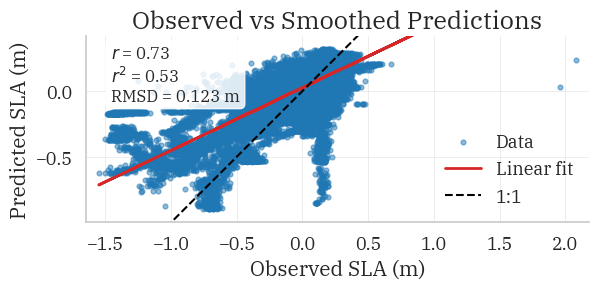

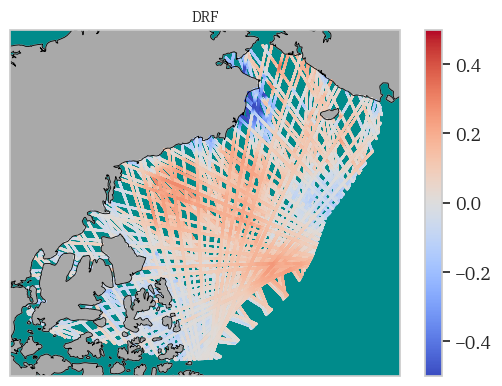

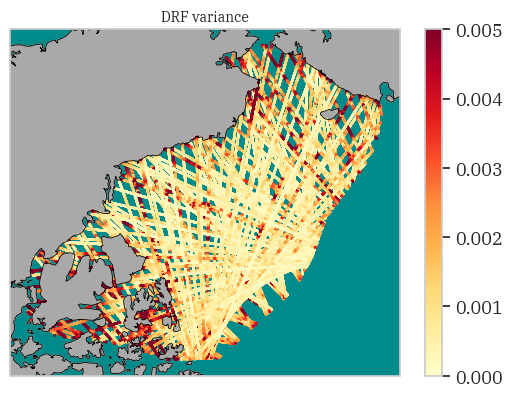

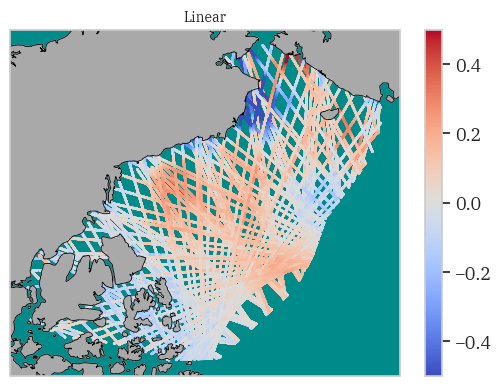

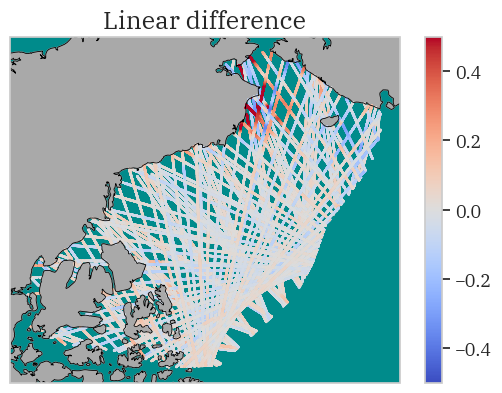

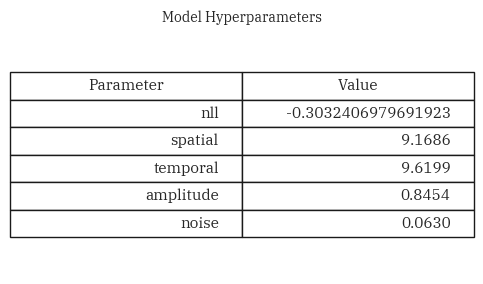

In [21]:
plotting(dup_tracks, cs2s3_full_df, cs2s3_csv_df)

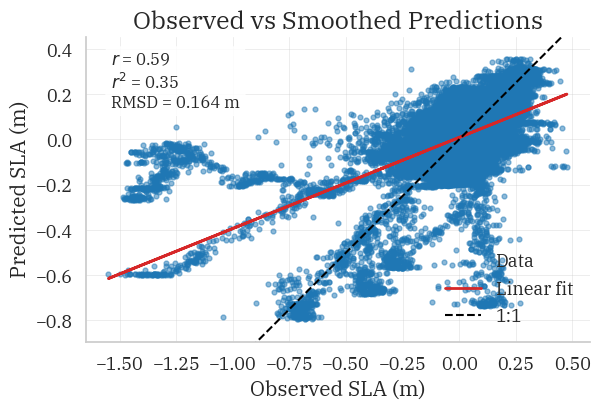

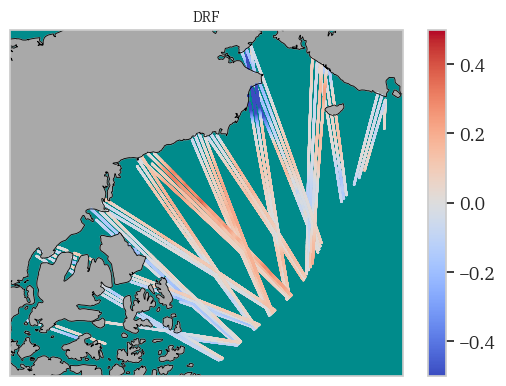

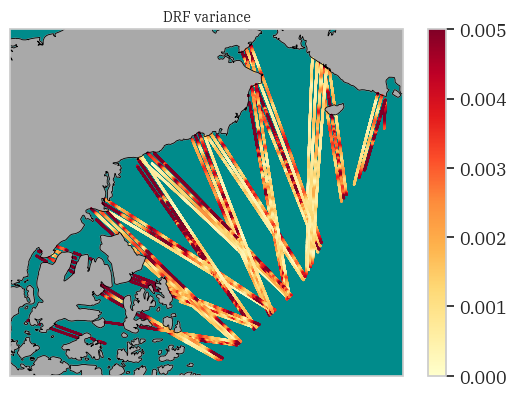

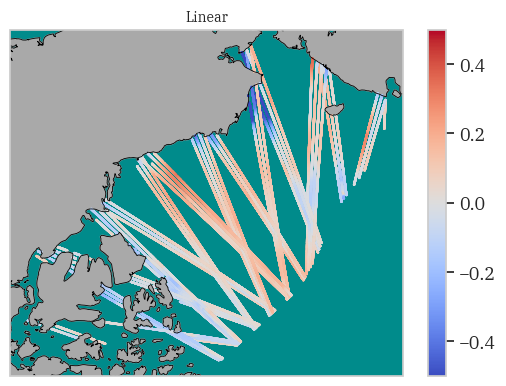

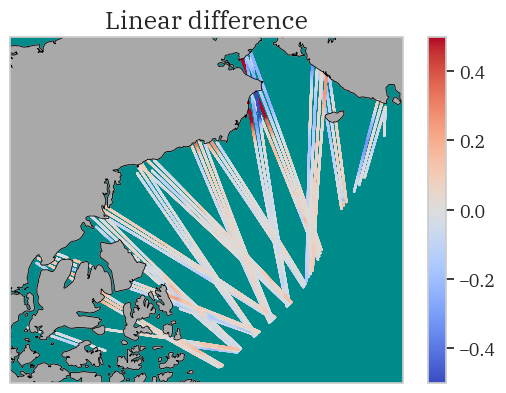

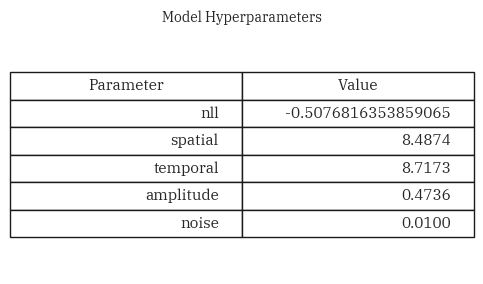

In [22]:
plotting(tracks_in_cs2, cs2_full_df, cs2_csv_df)

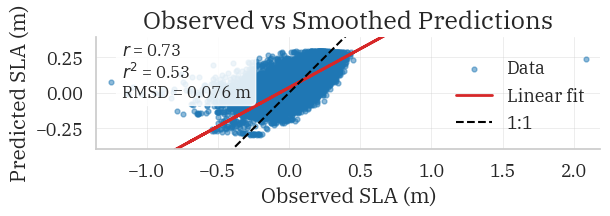

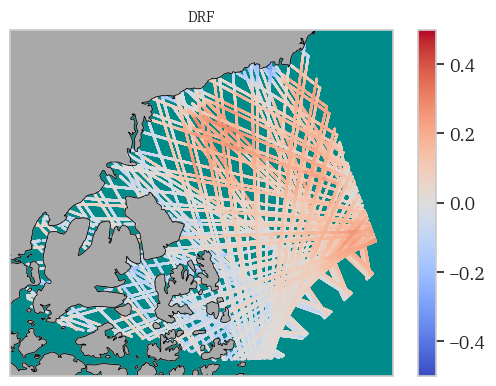

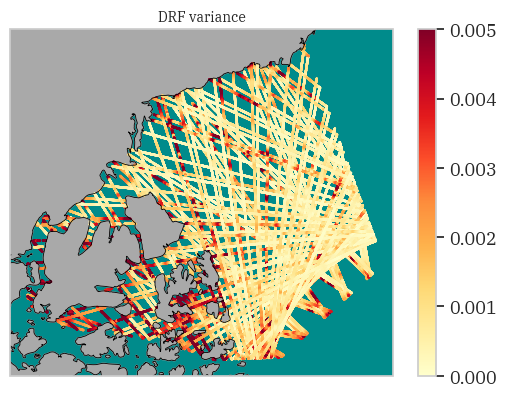

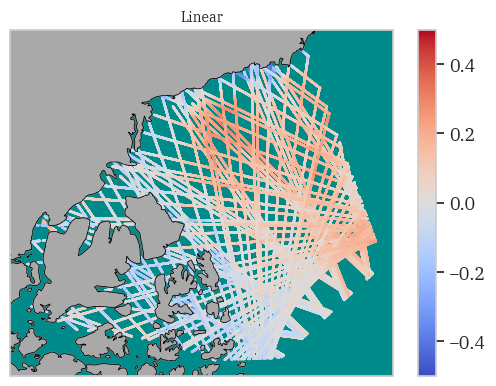

/tmp/ipykernel_1568044/387373555.py:373: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_df['lin_diff'] = full_df['f*']-full_df['f_lin']


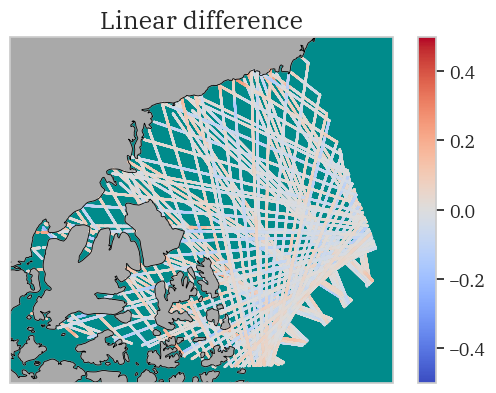

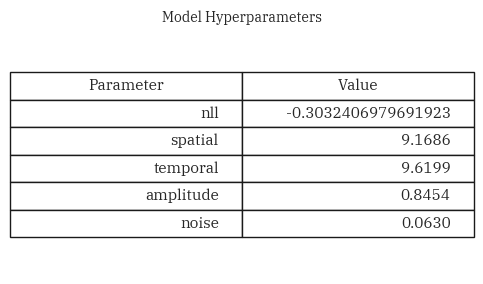

In [23]:
full_nice_df = cs2s3_full_df.loc[(cs2s3_full_df['lon']>-160) & (cs2s3_full_df['lon']<-90)]
nice_tracks = full_nice_df['track'].unique()

plotting(nice_tracks, full_nice_df, cs2s3_csv_df)

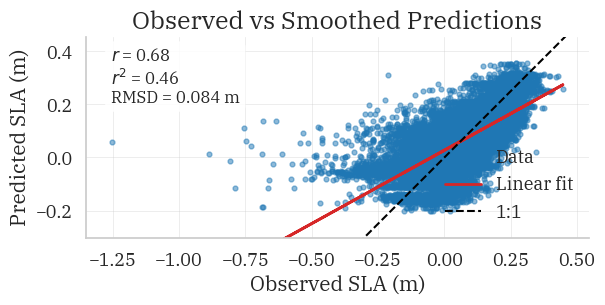

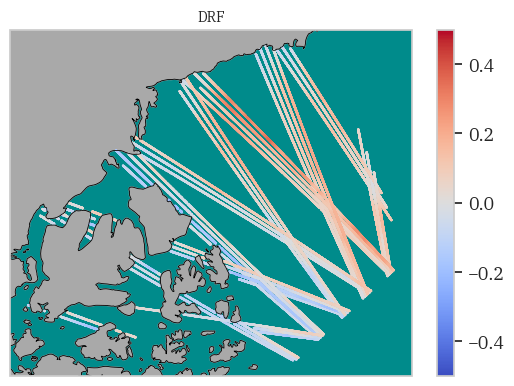

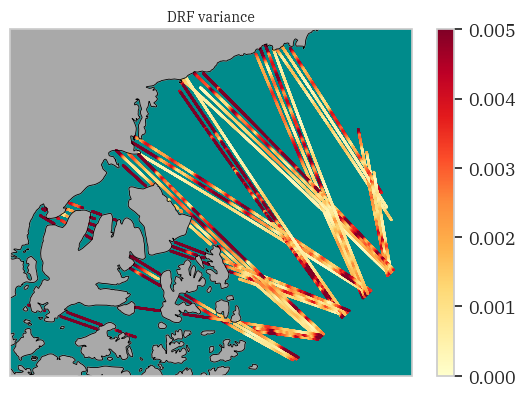

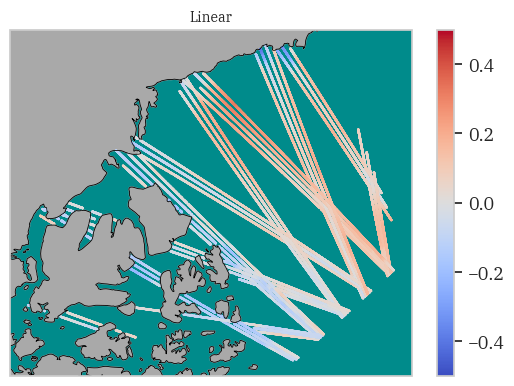

/tmp/ipykernel_1568044/387373555.py:373: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_df['lin_diff'] = full_df['f*']-full_df['f_lin']


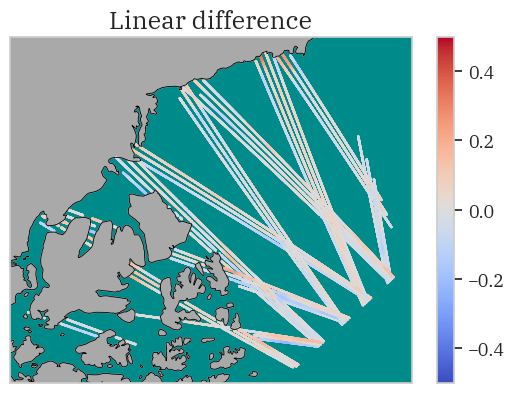

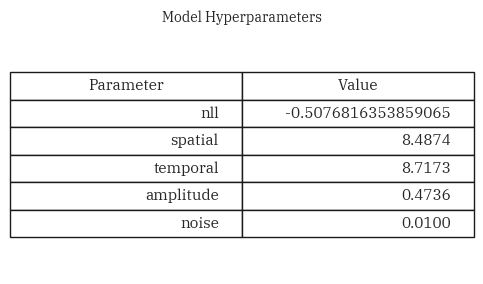

In [24]:
cs2_nice_df = cs2_full_df.loc[(cs2_full_df['lon']>-160) & (cs2_full_df['lon']<-90)]
cs2_nice_tracks = cs2_nice_df['track'].unique()

plotting(cs2_nice_tracks, cs2_nice_df, cs2_csv_df)

In [25]:
#save
cs2s3_full_df.to_csv('/home/mhen/comparison/data/cs2s3_4day_drf.csv')
cs2_full_df.to_csv('/home/mhen/comparison/data/cs2_4day_drf.csv')